In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import scipy.io
import matplotlib.pyplot as plt
import os
import sys

sys.path.append('../../STACAME/')

import STACAME

import warnings
warnings.filterwarnings("ignore")

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:


data_path =  '../Data/Macaque/'
section_name_list = ['Macaque1_T40', 'Macaque1_T42', 'Macaque1_T44', 'Macaque1_T46', 
                                'Macaque1_T48','Macaque1_T50', 'Macaque1_T52', 'Macaque1_T54', 
                                'Macaque1_T56', 'Macaque1_T58', 'Macaque1_T60', 'Macaque1_T62', 
                                'Macaque1_T64', 'Macaque1_T66', 'Macaque1_T68', 'Macaque1_T72', 
                                'Macaque1_T74', 'Macaque1_T76', 'Macaque1_T80', 'Macaque1_T82', 
                                'Macaque1_T84', 'Macaque1_T86', 'Macaque1_T88', 'Macaque1_T90', 
                                'Macaque1_T92', 'Macaque1_T94', 'Macaque1_T96', 'Macaque1_T98',
                                'Macaque1_T100', 'Macaque1_T102', 'Macaque1_T104', 'Macaque1_T106', 
                                'Macaque1_T108', 'Macaque1_T110']

# T40, T42, T44, T46, T48,T50, T52, T54, T56, T58, T60, T62, T64, T66, T68, T72, T74, T76, T80, T82, T84, T86, T88, T90, T92, T94, T96, T98,T100, T102, T104, T106, T108, T110

#section_name_list = ['Macaque1_T40', 'Macaque1_T42', 'Macaque1_T44']

sect_dict = {}
adata_raw_list = []
for section_name in section_name_list:
    save_section_name = section_name
    section_name = section_name + '.h5ad'
    adata = sc.read_h5ad(data_path + section_name)
    print(adata)
    adata.obs['batch_name'] = save_section_name
    adata.obs['slice_name'] = save_section_name
    adata.obs['slice'] = save_section_name
    adata.obs['species_id'] = 'Macaque'
    adata.obs['region_name'] = adata.obs['annotation']
    adata.obsm['loc_use'] = adata.obsm['spatial'] 
    adata.obs['array_row'] = adata.obsm['spatial'][:, 0]
    adata.obs['array_col'] = adata.obsm['spatial'][:, 1]
    adata_raw_list.append(adata)
    print(type(adata.X))
    sect_dict[save_section_name  + '_load'] = adata.n_obs
    #adata.write_h5ad(data_path + save_section_name  + '_load' + '.h5ad')

macaque_sect_names = list(sect_dict.keys())


AnnData object with n_obs × n_vars = 19910 × 15388
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area', 'Bergmann', 'Endothelial', 'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'OPC', 'Purkinje', 'UBC', 'Astrocyte', 'Choroid', 'Microglia', 'ODC', 'cluster', 'annotation'
    var: 'geneID', 'features'
    uns: 'annotation_colors'
    obsm: 'spatial'
<class 'scipy.sparse._csr.csr_matrix'>
AnnData object with n_obs × n_vars = 31811 × 15606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area', 'Bergmann', 'Endothelial', 'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'OPC', 'Purkinje', 'UBC', 'Astrocyte', 'Choroid', 'Microglia', 'ODC', 'cluster', 'annotation'
    var: 'geneID', 'features'
    uns: 'annotation_colors'
    obsm: 'spatial'
<class 'scipy.sparse._csr.csr_matrix'>
AnnData object with n_obs × n_vars = 53264 × 15744
    obs: 'orig.ident', 'nCo

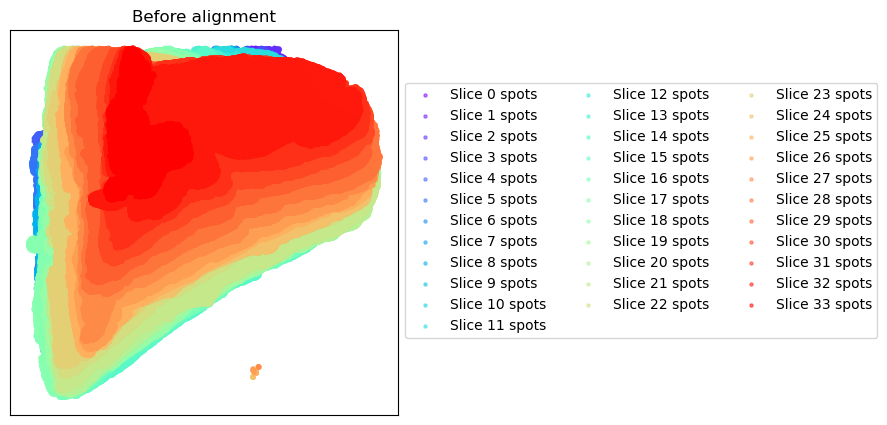

Using the Iterative Closest Point algorithm for alignemnt.
Detecting edges...
Aligning edges...
[[  0.81260575   0.58281377 106.35700036]
 [ -0.58281377   0.81260575 313.6339896 ]
 [  0.           0.           1.        ]]
[[  0.99900304   0.04464225 -16.13955317]
 [ -0.04464225   0.99900304  23.33534196]
 [  0.           0.           1.        ]]
[[ 9.98175390e-01 -6.03812148e-02 -1.57622894e+01]
 [ 6.03812148e-02  9.98175390e-01 -1.02315434e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[[   0.98465977   -0.17448536   50.48991684]
 [   0.17448536    0.98465977 -140.40167629]
 [   0.            0.            1.        ]]
[[ 9.99820839e-01  1.89285530e-02 -2.97926546e+00]
 [-1.89285530e-02  9.99820839e-01 -6.32604959e+01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[[ 9.99994629e-01 -3.27751823e-03 -1.82758833e-02]
 [ 3.27751823e-03  9.99994629e-01  5.48695837e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[[  0.99800555  -0.06312625  19.98676817]
 [  0.0631

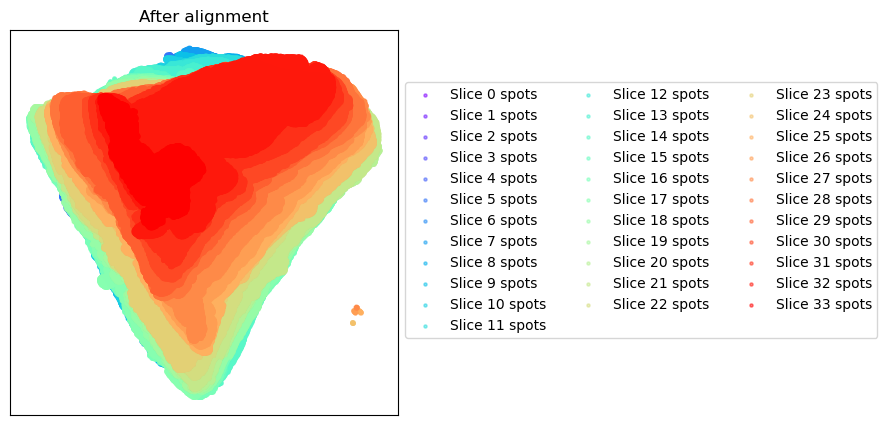

In [3]:
adata_st_list = STACAME.align_spots(adata_raw_list,
                                           plot=True,
                                           data_type="Stereo-seq",
                                           coor_key="spatial",
                                           method= 'icp',
                                           test_all_angles=False,
                                           subsampling = True,
                                           subsampling_rate = 0.05)

In [4]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import scipy.sparse
import matplotlib
import matplotlib.pyplot as plt
from STACAME.align_tools import *
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from matplotlib import cm

In [5]:
macaque_df = pd.read_csv('../Data/slicedistance/Macaque.csv')
print(macaque_df)
macaque_df = macaque_df.set_index('Slice')

slice_distance_list = []
for section_name in section_name_list:
    name = section_name.split('_')[1]
    slice_distance_list.append(macaque_df.loc[name, :].values[0])

print(slice_distance_list)

# Macaque: resolution - 500um
slice_distance_list = [x * 1000/500 for x in slice_distance_list]
slice_dist_micron = [slice_distance_list[i+1] - slice_distance_list[i] for i in range(0, len(slice_distance_list)-1)]

          Slice  EBZ (mm) / Midline (mm)
0           T40                     3.72
1           T42                     3.22
2           T44                     2.72
3           T46                     2.22
4           T48                     1.69
..          ...                      ...
56  T369\t-6.89                      NaN
57  T370\t-6.99                      NaN
58  T371\t-7.08                      NaN
59  T372\t-7.18                      NaN
60  T373\t-7.28                      NaN

[61 rows x 2 columns]
[3.72, 3.22, 2.72, 2.22, 1.69, 1.22, 0.71, 0.22, -0.28, -0.79, -1.29, -1.8, -2.3, -2.8, -3.3, -4.3, -4.8, -5.3, -6.3, -6.8, -7.3, -7.8, -8.3, -8.8, -9.3, -9.79, -10.25, -10.74, -11.24, -11.74, -12.24, -12.74, -13.24, -13.74]


In [6]:
def preprocess(adata_st_list_input, # list of spatial transcriptomics (ST) anndata objects
               adata_ref_input, # reference single-cell anndata object
               celltype_ref_col="celltype", # column of adata_ref_input.obs for cell type information
               sample_col=None, # column of adata_ref_input.obs for batch labels
               celltype_ref=None, # specify cell types to use for deconvolution
               n_hvg_group=500, # number of highly variable genes for reference anndata
               three_dim_coor=None, # if not None, use existing 3d coordinates in shape [# of total spots, 3]
               coor_key="spatial_aligned", # "spatial_aligned" by default
               rad_cutoff=None, # cutoff radius of spots for building graph
               rad_coef=1.1, # if rad_cutoff=None, rad_cutoff is the minimum distance between spots multiplies rad_coef
               slice_dist_micron=None, # pairwise distances in micrometer for reconstructing z-axis 
               prune_graph_cos=False, # prune graph connections according to cosine similarity
               cos_threshold=0.5, # threshold for pruning graph connections
               c2c_dist=100, # center to center distance between nearest spots in micrometer
               ):

    adata_st_list = adata_st_list_input.copy()

    print("Finding highly variable genes...")
    adata_ref = adata_ref_input.copy()
    adata_ref.var_names_make_unique()
    # Remove mt-genes
    adata_ref = adata_ref[:, np.array(~adata_ref.var.index.isna())
                          & np.array(~adata_ref.var_names.str.startswith("mt-"))
                          & np.array(~adata_ref.var_names.str.startswith("MT-"))]
    if celltype_ref is not None:
        if not isinstance(celltype_ref, list):
            raise ValueError("'celltype_ref' must be a list!")
        else:
            adata_ref = adata_ref[[(t in celltype_ref) for t in adata_ref.obs[celltype_ref_col].values.astype(str)], :]
    else:
        celltype_counts = adata_ref.obs[celltype_ref_col].value_counts()
        celltype_ref = list(celltype_counts.index[celltype_counts > 1])
        adata_ref = adata_ref[[(t in celltype_ref) for t in adata_ref.obs[celltype_ref_col].values.astype(str)], :]

    # Remove cells and genes with 0 counts
    sc.pp.filter_cells(adata_ref, min_genes=1)
    sc.pp.filter_genes(adata_ref, min_cells=1)

    # Concatenate ST adatas
    for i in range(len(adata_st_list)):
        adata_st_new = adata_st_list[i].copy()
        adata_st_new.var_names_make_unique()
        # Remove mt-genes
        adata_st_new = adata_st_new[:, (np.array(~adata_st_new.var.index.str.startswith("mt-")) 
                                    & np.array(~adata_st_new.var.index.str.startswith("MT-")))]
        adata_st_new.obs.index = adata_st_new.obs.index + "-slice%d" % i
        adata_st_new.obs['slice'] = i
        if i == 0:
            adata_st = adata_st_new
        else:
            #genes_shared = adata_st.var.index & adata_st_new.var.index
            genes_shared = adata_st.var.index.intersection(adata_st_new.var.index)
            adata_st = adata_st[:, genes_shared].concatenate(adata_st_new[:, genes_shared], index_unique=None)

    adata_st.obs["slice"] = adata_st.obs["slice"].values.astype(int)

    # Take gene intersection
    genes = list(adata_st.var.index.intersection(adata_ref.var.index))
    adata_ref = adata_ref[:, genes]
    adata_st = adata_st[:, genes]

    # Select hvgs
    adata_ref_log = adata_ref.copy()
    sc.pp.log1p(adata_ref_log)
    hvgs = select_hvgs(adata_ref_log, celltype_ref_col=celltype_ref_col, num_per_group=n_hvg_group)

    print("%d highly variable genes selected." % len(hvgs))
    adata_ref = adata_ref[:, hvgs]

    # Build 3D coordinates 
    if three_dim_coor is None:

        # The first adata in adata_list is used as a reference for computing cutoff radius of spots
        adata_st_ref = adata_st_list[0].copy()
        loc_ref = np.array(adata_st_ref.obsm[coor_key])
        pair_dist_ref = pairwise_distances(loc_ref)
        min_dist_ref = np.sort(np.unique(pair_dist_ref), axis=None)[1]

        if rad_cutoff is None:
            # The radius is computed base on the attribute "adata.obsm['spatial']"
            rad_cutoff = min_dist_ref * rad_coef
        print("Radius for graph connection is %.4f." % rad_cutoff)

        # Use the attribute "adata.obsm['spatial_aligned']" to build a global graph
        if slice_dist_micron is None:
            loc_xy = pd.DataFrame(adata_st.obsm['spatial_aligned']).values
            loc_z = np.zeros(adata_st.shape[0])
            loc = np.concatenate([loc_xy, loc_z.reshape(-1, 1)], axis=1)
        else:
            if len(slice_dist_micron) != (len(adata_st_list) - 1):
                raise ValueError("The length of 'slice_dist_micron' should be the number of adatas - 1 !")
            else:
                loc_xy = pd.DataFrame(adata_st.obsm['spatial_aligned']).values
                loc_z = np.zeros(adata_st.shape[0])
                dim = 0
                for i in range(len(slice_dist_micron)):
                    dim += adata_st_list[i].shape[0]
                    loc_z[dim:] += slice_dist_micron[i] * (min_dist_ref / c2c_dist)
                loc = np.concatenate([loc_xy, loc_z.reshape(-1, 1)], axis=1)

    # If 3D coordinates already exists
    else:
        if rad_cutoff is None:
            raise ValueError("Please specify 'rad_cutoff' for finding 3D neighbors!")
        loc = three_dim_coor

    # pair_dist = pairwise_distances(loc)
    # G = (pair_dist < rad_cutoff).astype(float)

    # if prune_graph_cos:
    #     pair_dist_cos = pairwise_distances(adata_st.X, metric="cosine") # 1 - cosine_similarity
    #     G_cos = (pair_dist_cos < (1 - cos_threshold)).astype(float)
    #     G = G * G_cos

    #print('%.4f neighbors per cell on average.' % (np.mean(np.sum(G, axis=1)) - 1))
    #adata_st.obsm["graph"] = G
    adata_st.obsm["3D_coor"] = loc

    return adata_st


def select_hvgs(adata_ref, celltype_ref_col, num_per_group=200):
    sc.tl.rank_genes_groups(adata_ref, groupby=celltype_ref_col, method="t-test", key_added="ttest", use_raw=False)
    markers_df = pd.DataFrame(adata_ref.uns['ttest']['names']).iloc[0:num_per_group, :]
    genes = sorted(list(np.unique(markers_df.melt().value.values)))
    return genes

In [7]:
adata_ref = sc.read_h5ad('../Data/scRNAseq/Macaque.sn_load.h5ad')
print(adata_st_list[0].var.index)
print(adata_ref.var.index)
print(adata_st_list[0].var.index.intersection(adata_ref.var.index))
adata_st = preprocess(adata_st_list,
                                                  adata_ref,
                                                  celltype_ref_col="celltype",
                                                  celltype_ref=None,
                                                  sample_col=None,
                                                  slice_dist_micron=slice_dist_micron,
                                                  n_hvg_group=500)

print(adata_st)


Index(['NOC2L', 'KLHL17', 'AGRN', 'SDF4', 'UBE2J2', 'ACAP3', 'PUSL1', 'INTS11',
       'CPTP', 'TAS1R3',
       ...
       'SNORA28', 'CHRNB4', 'TRAV16', 'FABP9', 'LACRT', 'AGXT', 'CD3E',
       'SOX21', 'S1PR2', 'ZNF469'],
      dtype='object', name='features', length=15388)
Index(['CALN1', 'CDC73', 'VWC2', 'SFXN1', 'PCNX2', 'LHFPL6', 'AFF3', 'APOE',
       'ND3', 'SYNE1',
       ...
       'ENSMFAG00000025024', 'ENSMFAG00000013337', 'ENSMFAG00000013677',
       'SNORD41', 'ENSMFAG00000014293', 'ENSMFAG00000044233',
       'ENSMFAG00000006304', 'ENSMFAG00000033721', 'SPAAR',
       'ENSMFAG00000007852'],
      dtype='object', length=21830)
Index(['NOC2L', 'KLHL17', 'AGRN', 'SDF4', 'UBE2J2', 'ACAP3', 'PUSL1', 'INTS11',
       'CPTP', 'TAS1R3',
       ...
       'SNORA28', 'CHRNB4', 'TRAV16', 'FABP9', 'LACRT', 'AGXT', 'CD3E',
       'SOX21', 'S1PR2', 'ZNF469'],
      dtype='object', length=15361)
Finding highly variable genes...
3732 highly variable genes selected.
Radius for graph conn

In [8]:
save_path = './Macaque/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

print(adata_st)

adata_st.write(save_path + 'adata_st.h5ad')

coor_3d = pd.DataFrame(data=adata_st.obsm['3D_coor'], index=adata_st.obs.index, columns=['x', 'y', 'z'])
coor_3d.to_csv(os.path.join(save_path, "3D_coordinates.csv"))

print(coor_3d)



AnnData object with n_obs × n_vars = 8016404 × 15024
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area', 'Bergmann', 'Endothelial', 'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'OPC', 'Purkinje', 'UBC', 'Astrocyte', 'Choroid', 'Microglia', 'ODC', 'cluster', 'annotation', 'batch_name', 'slice_name', 'slice', 'species_id', 'region_name', 'array_row', 'array_col', 'batch'
    var: 'geneID', 'features'
    obsm: 'spatial', 'loc_use', 'spatial_aligned', '3D_coor'
                            x           y       z
1879_1010-slice0   682.714410   29.026729  0.0000
1860_1029-slice0   707.527153   39.338268  0.0000
1861_1024-slice0   704.694776   35.098262  0.0000
1877_1108-slice0   721.960898  118.847179  0.0000
1907_1142-slice0   707.205964  161.722486  0.0000
...                       ...         ...     ...
2159_1505-slice33  501.760252  203.881137 -0.3492
2151_1294-slice33  395.812499   21.233735 -0.3492
2144_1492-sli